**Geneformer and Tokenization**

In [ ]:
!if [ -d "Geneformer" ]; then rm -rf Geneformer; fi

**Transfer learning enables predictions in network biology**

https://www.nature.com/articles/s41586-023-06139-9

Pretrained Geneformer architecture. Each single-cell transcriptome is encoded into a rank value encoding that then proceeds through six layers of transformer encoder units with parameters as follows: input size of 2,048 (fully represents 93% of rank value encodings in Geneformer-30M),**256 embedding dimensions, four attention heads per layer and feed-forward size of 512. Geneformer uses full dense self-attention across the input size of 2,048**. Extractable outputs include contextual gene and cell embeddings, contextual attention weights and contextual predictions.

The rank value encoding of the transcriptome of each single cell then proceeds through six transformer encoder units, each composed of a self-attention layer and feed forward neural network layer. Pretraining was accomplished using a masked learning objective, which has been shown in other informational fields1,2 to improve generalizability of the foundational knowledge learned during pretraining for a wide range of downstream fine-tuning objectives. During pretraining, 15% of the genes within each transcriptome were masked, and the model was trained to predict which gene should be within each masked position in that specific cell state using the context of the remaining unmasked genes

In [ ]:
# Clone fresh
!git lfs install
!git clone https://huggingface.co/ctheodoris/Geneformer

# IMPORTANT: Change directory BEFORE installing
%cd /content/Geneformer

# Verify you're in the right place
!pwd
!ls -la  # Should see setup.py or pyproject.toml

# Now install
!pip install .

Git LFS initialized.
Cloning into 'Geneformer'...
remote: Enumerating objects: 1193, done.
remote: Counting objects: 100% (235/235), done.
remote: Compressing objects: 100% (235/235), done.
remote: Total 1193 (delta 136), reused 0 (delta 0), pack-reused 958 (from 1)
Receiving objects: 100% (1193/1193), 5.77 MiB | 8.87 MiB/s, done.
Resolving deltas: 100% (746/746), done.
Filtering content: 100% (24/24), 3.32 GiB | 235.70 MiB/s, done.
/content/Geneformer
/content/Geneformer
total 1235900
drwxr-xr-x 11 root root       4096 Jul 14 16:23 .
drwxr-xr-x  1 root root       4096 Jul 14 16:23 ..
-rw-r--r--  1 root root        591 Jul 14 16:23 config.json
drwxr-xr-x  3 root root       4096 Jul 14 16:23 docs
drwxr-xr-x  3 root root       4096 Jul 14 16:23 examples
drwxr-xr-x  3 root root       4096 Jul 14 16:23 fine_tuned_models
drwxr-xr-x  4 root root       4096 Jul 14 16:23 geneformer
drwxr-xr-x  2 root root       4096 Jul 14 16:23 Geneformer-V1-10M
drwxr-xr-x  2 root root       4096 Jul 14 16:23

In [ ]:
!pip install scanpy
!pip install loompy

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
Cell types:
louvain
CD4 T cells          1144
CD14+ Monocytes       480
B cells               342
CD8 T cells           316
NK cells              154
FCGR3A+ Monocytes     150
Dendritic cells        37
Megakaryocytes         15
Name: count, dtype: int64


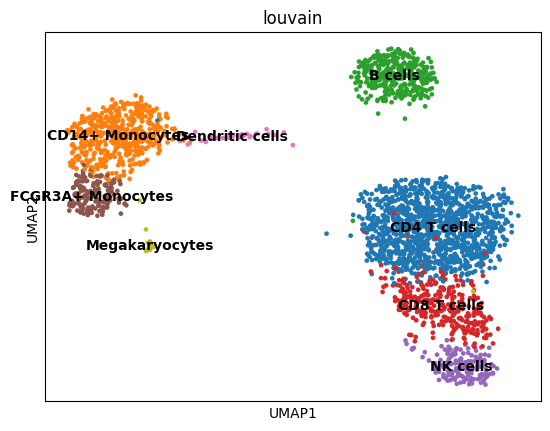

In [ ]:
import scanpy as sc
import pandas as pd

# Download the classic PBMC3k dataset
adata = sc.datasets.pbmc3k_processed()
print(adata)

# This gives you a pre-processed dataset with:
# - 2,638 cells × 1,838 genes
# - UMAP, PCA, and clustering already computed
# - Cell type annotations

# Basic exploration
print("Cell types:")
print(adata.obs['louvain'].value_counts())

# Quick UMAP plot
sc.pl.umap(adata, color='louvain', legend_loc='on data')

In [ ]:
import numpy as np
print(f"Dataset shape: {adata.shape}")

print("=== GENE METADATA OVERVIEW ===")
print(f"First 5 genes: {adata.var.index[:5].tolist()}")

# Check if genes are Ensembl IDs
if adata.var.index[0].startswith('ENSG'):
    print("✓ Genes are already Ensembl IDs")
    adata.var['ensembl_id'] = adata.var.index
else:
    print("⚠ Genes are gene symbols, need to convert to Ensembl IDs")
    # You would use your gene mapping approach here

print("=== CELL METADATA OVERVIEW ===")
print(f"Number of cells: {adata.n_obs}")
print(f"Number of metadata columns: {adata.obs.shape[1]}")
print(f"Cell index name: {adata.obs.index.name}")

print("\n=== METADATA COLUMNS ===")
print("Available columns:", list(adata.obs.columns))
print("\nColumn data types:")
print(adata.obs.dtypes)

print("\n=== FIRST 10 CELLS METADATA ===")
print(adata.obs.head(10))

print("\n=== METADATA SUMMARY STATISTICS ===")
# For numeric columns
numeric_cols = adata.obs.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print("Numeric columns summary:")
    print(adata.obs[numeric_cols].describe())

Dataset shape: (2638, 1838)
=== GENE METADATA OVERVIEW ===
First 5 genes: ['TNFRSF4', 'CPSF3L', 'ATAD3C', 'C1orf86', 'RER1']
⚠ Genes are gene symbols, need to convert to Ensembl IDs
=== CELL METADATA OVERVIEW ===
Number of cells: 2638
Number of metadata columns: 4
Cell index name: index

=== METADATA COLUMNS ===
Available columns: ['n_genes', 'percent_mito', 'n_counts', 'louvain']

Column data types:
n_genes            int64
percent_mito     float32
n_counts         float32
louvain         category
dtype: object

=== FIRST 10 CELLS METADATA ===
                  n_genes  percent_mito  n_counts            louvain
index                                                               
AAACATACAACCAC-1      781      0.030178    2419.0        CD4 T cells
AAACATTGAGCTAC-1     1352      0.037936    4903.0            B cells
AAACATTGATCAGC-1     1131      0.008897    3147.0        CD4 T cells
AAACCGTGCTTCCG-1      960      0.017431    2639.0    CD14+ Monocytes
AAACCGTGTATGCG-1      522      0.01


*Resuming the previous code described in the script Geneformer_Anndata_Loom.ipynb*

Tokenizing .loom single cell RNA-seq data to rank value encoding .dataset format.

**Input data** is a directory with .loom files containing raw counts from single cell RNAseq data, including all genes detected in the transcriptome without feature selection.

**Genes** should be labeled with **Ensembl IDs (row attribute "ensembl_id")**, which provide a unique identifer for conversion to tokens. Other forms of gene annotations (e.g. gene names) can be converted to Ensembl IDs via Ensembl Biomart. Cells should be labeled with the total read count in the cell (column attribute "n_counts") to be used for normalization.

**No cell metadata** is required, but custom cell attributes may be passed onto the tokenized dataset by providing a dictionary of custom attributes to be added, which is formatted as loom_col_attr_name : desired_dataset_col_attr_name.

*For example, if the original .loom dataset has column attributes "cell_type" and "organ_major" and one would like to retain these attributes as labels in the tokenized dataset with the new names "cell_type" and "organ", respectively, the following custom attribute dictionary should be provided: {"cell_type": "cell_type", "organ_major": "organ"}.*

Additionally, if the original .loom file contains a cell column attribute called **"filter_pass",** this column will be used as a binary indicator of whether to include these cells in the tokenized data. All cells with "1" in this attribute will be tokenized, whereas the others will be excluded. One may use this column to indicate QC filtering or other criteria for selection for inclusion in the final tokenized dataset.

If one's data is in other formats besides .loom, one can use the relevant tools (such as Anndata tools) to convert the file to a .loom format prior to running the transcriptome tokenizer.

In [ ]:
# If you want to use Loom syntax, you need to: Read the saved Loom file

# import loompy

# Read the Loom file you created
# with loompy.connect("/content/drive/My Drive/geneformer_test1/pbms.option1.loom") as ds:
#    print(ds.shape)
#    print("Row attributes (genes):", ds.ra.keys())
#    print("Column attributes (cells):", ds.ca.keys())
#    print("First gene expression:", ds[:, 0])

To use the loom files generated in the previous script : *Geneformer_Anndata_Loom.py*

In [ ]:
%pwd
%ls -1
!ls -1 ./data

build/
config.json
data/
docs/
examples/
fine_tuned_models/
geneformer/
geneformer.egg-info/
Geneformer-V1-10M/
Geneformer-V2-104M/
Geneformer-V2-104M_CLcancer/
Geneformer-V2-316M/
generation_config.json
MANIFEST.in
model.safetensors
README.md
requirements.txt
setup.py
training_args.bin
pbmc3k_processed.h5ad


**Key Differences :: AnnData <>  Loom**

Description ::  adata.var <> ds.ra

Gene/row metadata :: adata.obs <> ds.ca

Cell/column metadata :: adata.X <> ds[:,:]

Expression :: matrixadata.var.columns <> ds.ra.keys()


**You can find some PBMC .h5ad files on Figshare:**

pbmc.h5ad by Openproblems Bio: This file is available for download. It's 19.07 MB. You'd need to check its internal structure (i.e., adata.var.index and adata.obs) to confirm if it already has Ensembl IDs and a n_counts equivalent.

Link: https://figshare.com/articles/dataset/pbmc_h5ad/20186285

scanpy-pbmc3k.h5ad: Another PBMC 3k dataset formatted for Scanpy is also available. Similarly, you'd need to inspect its gene IDs.

Link: https://figshare.com/articles/dataset/scanpy-pbmc3k_h5ad/16447278

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Check if the file exists
file_path = "/content/drive/My Drive/geneformer_test1/pbms.option1.loom"

if os.path.exists(file_path):
    file_size = os.path.getsize(file_path) / 1024**2
    print(f"✅ File EXISTS: {file_path}")
    print(f"📁 File size: {file_size:.2f} MB")
else:
    print(f"❌ File NOT FOUND: {file_path}")

✅ File EXISTS: /content/drive/My Drive/geneformer_test1/pbms.option1.loom
📁 File size: 9.01 MB


In [ ]:
# Check current working directory (prints a string, not magic)
import os
print(os.getcwd())


/content/Geneformer


In [ ]:
%pwd
# Create directories (with -p so it won’t complain if they already exist)
!mkdir -p /content/pbmc_input
!mkdir -p /content/pbmc_token
# List directories under /content
!ls -1d /content/*

/content/data
/content/drive
/content/Geneformer
/content/pbmc_input
/content/pbmc_input_adata_from_scanpy_package
/content/pbmc_token
/content/pbmc_token2
/content/pbmc_token3
/content/pbmc_token4
/content/pbmc_token5
/content/pbmc_token6
/content/sample_data


In [ ]:
# import scanpy as sc
# import numpy as np

# Read H5AD file
# adata_fs = sc.read_h5ad("/content/drive/My Drive/geneformer_test1/pbmc3k_figshare_scanpy.h5ad")

# print(f"Data shape: {adata_fs.shape}")
# print(f"Gene format: {adata_fs.var.index[:5].tolist()}")
# print(f"Obs columns: {list(adata_fs.obs.columns)}")

# Check and prepare for Geneformer
# print("\n=== Preparing for Geneformer ===")
# print("\n Need Ensembl ID \n")

# Check gene name format
# print("=== GENE NAME FORMAT CHECK ===")
# print(f"Total genes: {len(adata_fs.var.index)}")

# Sample of gene names
# print(f"First 10 gene names: {adata_fs.var.index[:10].tolist()}")
# print(f"Last 5 gene names: {adata_fs.var.index[-5:].tolist()}")

# Check for Ensembl ID patterns
# ens_patterns = {
#    'ENSG': 0,  # Human genes
#    'ENSM': 0,  # Mouse genes
#    'ENS': 0,   # Any Ensembl ID
# }

# Count different patterns
# for gene in adata_fs.var.index:
#    gene_str = str(gene)
#    if gene_str.startswith('ENSG'):
#        ens_patterns['ENSG'] += 1
#    elif gene_str.startswith('ENSM'):
#        ens_patterns['ENSM'] += 1
#    elif 'ENS' in gene_str:
#        ens_patterns['ENS'] += 1

# print(f"\n=== ENSEMBL ID ANALYSIS ===")
# print(f"Human Ensembl IDs (ENSG*): {ens_patterns['ENSG']}")
# print(f"Mouse Ensembl IDs (ENSM*): {ens_patterns['ENSM']}")
# print(f"Other Ensembl IDs (ENS*): {ens_patterns['ENS']}")

**To use the loom file generated in a previous script  :**

In [ ]:
!pwd

import loompy

# Load loom file using Scanpy
adata = sc.read_loom("/content/drive/My Drive/geneformer_test1/pbmc.option1.loom")

# Convert the expression matrix (sparse) to dense and show as DataFrame
df_expr = pd.DataFrame(adata.X.toarray(),
                       index=adata.obs_names,
                       columns=adata.var_names)

# Show the first 5 cells × first 5 genes
print(df_expr.iloc[:5, :5])

# View cell or gene metadata

# Cell metadata (obs):
print(adata.obs.head())

# Gene metadata (var):
print(adata.var.head())

# Ensure the output directory exists
import os
os.makedirs("/content/pbmc_input", exist_ok=True)

# Save the AnnData object
print("\nSaving AnnData object to Loom format: /content/pbmc_input/pbmc.option1.loom")
adata.write_loom("/content/pbmc_input/pbmc.option1.loom")
print("✅ Save complete!")

/content/Geneformer


/usr/local/lib/python3.11/dist-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/usr/local/lib/python3.11/dist-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


     0    1    2    3    4
0  0.0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0  0.0
4  0.0  0.0  0.0  0.0  0.0
   cell_type  nCount_RNA  nFeature_RNA  n_counts obs_names  organ  \
0          1      2419.0           779    2419.0         0      1   
1          3      4903.0          1352    4900.0         1      3   
2          1      3147.0          1129    3147.0         2      1   
3          2      2639.0           960    2639.0         3      2   
4          6       980.0           521     980.0         4      6   

   organ_major  orig.ident  seurat_annotations  
0            1           0                   1  
1            3           0                   3  
2            1           0                   1  
3            2           0                   2  
4            6           0                   6  
        ensembl_id       features      gene_name var_names
0  ENSG00000237683     AL627309.1     AL627309.1         0
1  ENSG0000

In [ ]:
print("🔹 Cell metadata (obs):")
print(adata.obs.head())

🔹 Cell metadata (obs):
   cell_type  nCount_RNA  nFeature_RNA  n_counts obs_names  organ  \
0          1      2419.0           779    2419.0         0      1   
1          3      4903.0          1352    4900.0         1      3   
2          1      3147.0          1129    3147.0         2      1   
3          2      2639.0           960    2639.0         3      2   
4          6       980.0           521     980.0         4      6   

   organ_major  orig.ident  seurat_annotations  
0            1           0                   1  
1            3           0                   3  
2            1           0                   1  
3            2           0                   2  
4            6           0                   6  


In [ ]:
print("🔹 Gene metadata (obs):")
print(adata.var.head())

🔹 Gene metadata (obs):
        ensembl_id       features      gene_name var_names
0  ENSG00000237683     AL627309.1     AL627309.1         0
1  ENSG00000228463     AP006222.2     AP006222.2         1
2  ENSG00000228327  RP11-206L10.2  RP11-206L10.2         2
3  ENSG00000237491  RP11-206L10.9  RP11-206L10.9         3
4  ENSG00000225880      LINC00115      LINC00115         4


In [ ]:
!ls -la ../
!ls -la /content
!ls -la /content/Geneformer/
!ls -la /content/pbmc_input/
!ls -la /content/pbmc_token/

total 60
drwxr-xr-x  1 root root 4096 Jul 14 16:23 .
drwxr-xr-x  1 root root 4096 Jul 14 14:44 ..
drwxr-xr-x  4 root root 4096 Jul 10 13:34 .config
drwxr-xr-x  2 root root 4096 Jul 14 15:25 data
drwx------  5 root root 4096 Jul 14 14:49 drive
drwxr-xr-x 14 root root 4096 Jul 14 16:23 Geneformer
drwxr-xr-x  2 root root 4096 Jul 14 16:23 pbmc_input
drwxr-xr-x  2 root root 4096 Jul 14 16:20 pbmc_input_adata_from_scanpy_package
drwxr-xr-x  3 root root 4096 Jul 14 14:50 pbmc_token
drwxr-xr-x  3 root root 4096 Jul 14 14:50 pbmc_token2
drwxr-xr-x  3 root root 4096 Jul 14 14:50 pbmc_token3
drwxr-xr-x  3 root root 4096 Jul 14 14:51 pbmc_token4
drwxr-xr-x  3 root root 4096 Jul 14 14:51 pbmc_token5
drwxr-xr-x  3 root root 4096 Jul 14 15:35 pbmc_token6
drwxr-xr-x  1 root root 4096 Jul 10 13:35 sample_data
total 60
drwxr-xr-x  1 root root 4096 Jul 14 16:23 .
drwxr-xr-x  1 root root 4096 Jul 14 14:44 ..
drwxr-xr-x  4 root root 4096 Jul 10 13:34 .config
drwxr-xr-x  2 root root 4096 Jul 14 15:25 data


In [ ]:
!ls -la /content/pbmc_input/

total 8208
drwxr-xr-x 2 root root    4096 Jul 14 16:23 .
drwxr-xr-x 1 root root    4096 Jul 14 16:23 ..
-rw-r--r-- 1 root root 8396445 Jul 14 16:23 pbmc.option1.loom


In [ ]:
# Print dataset dimensions
print("=== DATASET DIMENSIONS ===")
print(f"📊 Number of cells: {adata.n_obs:,}")
print(f"🧬 Number of genes: {adata.n_vars:,}")
print(f"📏 Data shape: {adata.shape} (cells × genes)")

=== DATASET DIMENSIONS ===
📊 Number of cells: 2,700
🧬 Number of genes: 13,645
📏 Data shape: (2700, 13645) (cells × genes)


https://geneformer.readthedocs.io/en/latest/geneformer.tokenizer.html

**Geneformer tokenizer.**

**Input data:**

*Required format:* raw counts scRNAseq data without feature selection as .loom or anndata file.

*Required row (gene) attribute:* “ensembl_id”; Ensembl ID for each gene.

*Required col (cell) attribute:* “n_counts”; total read counts in that cell.

*Optional col (cell) attribute:* “filter_pass”; binary indicator of whether cell should be tokenized based on user-defined filtering criteria.

*Optional col (cell) attributes:* any other cell metadata can be passed on to the tokenized dataset as a custom attribute dictionary as shown below.

**Usage:**

```
from geneformer import TranscriptomeTokenizer
tk = TranscriptomeTokenizer({"cell_type": "cell_type", "organ_major": "organ"}, nproc=4)
tk.tokenize_data("data_directory", "output_directory", "output_prefix")

```

**Description:**


Input data is a directory with .loom or .h5ad files containing raw counts from single cell RNAseq data, including all genes detected in the transcriptome without feature selection. The input file type is specified by the argument file_format in the tokenize_data function.

The discussion below references the .loom file format, but the analagous labels are required for .h5ad files, just that they will be column instead of row attributes and vice versa due to the transposed format of the two file types.

Genes should be labeled with Ensembl IDs **(loom row attribute “ensembl_id”)**, which provide a unique identifer for conversion to tokens. Other forms of gene annotations (e.g. gene names) can be converted to Ensembl IDs via Ensembl Biomart. Cells should be labeled with the total read count in the cell (loom column attribute “n_counts”) to be used for normalization.

**No cell metadata is required**, but custom cell attributes may be passed onto the tokenized dataset by providing a dictionary of custom attributes to be added, which is formatted as loom_col_attr_name : desired_dataset_col_attr_name.* For example, if the original .loom dataset has column attributes “cell_type” and “organ_major” and one would like to retain these attributes as labels in the tokenized dataset with the new names “cell_type” and “organ”, respectively, the following custom attribute dictionary should be provided: {“cell_type”: “cell_type”, “organ_major”: “organ”}.*

Additionally, if the original .loom file contains a cell column attribute called **“filter_pass”**, this column will be used as a binary indicator of whether to include these cells in the tokenized data. All cells with “1” in this attribute will be tokenized, whereas the others will be excluded. One may use this column to indicate QC filtering or other criteria for selection for inclusion in the final tokenized dataset.

If one’s data is in other formats besides .loom or .h5ad, one can use the relevant tools (such as Anndata tools) to convert the file to a .loom or .h5ad format prior to running the transcriptome tokenizer.

**OF NOTE:**

Use model_version to auto-select settings for model version other than current default.

**For V1 model series (original Geneformer pretrained in 2021 on ~30M cells),** one must use correct corresponding token dictionary and gene median file, **set special_token to False, and set model_input_size to 2048.**
This argument enables auto-selection of these settings.

**For V2 model series**, **special_token must be True and model_input_size is 4096**.



`TranscriptomeTokenizer(custom_attr_name_dict=None, nproc=1, chunk_size=512, model_input_size=4096, special_token=True, collapse_gene_ids=True, model_version='V2', gene_median_file=FILEPATH, token_dictionary_file=FILEPATH, gene_mapping_file=FILEPATH)`


**Parameters:**


*custom_attr_name_dictNone, dict*

Dictionary of custom attributes to be added to the dataset.

Keys are the names of the attributes in the loom file.

Values are the names of the attributes in the dataset.

*nprocint*

Number of processes to use for dataset mapping.

*chunk_sizeint = 512*

Chunk size for anndata tokenizer.

*model_input_sizeint = 4096*
Max input size of model to truncate input to.

**For the V1 model series, should be 2048.
For the V2 model series, should be 4096.**

*special_tokenbool = True*

Adds CLS token before and EOS token after rank value encoding.

**For the V1 model series, should be False.
For the V2 model series, should be True.**

*collapse_gene_idsbool = True*

Whether to collapse gene IDs based on gene mapping dictionary.

*model_versionstr*

To auto-select settings for model version other than current default.

Current options:

**V1: models pretrained on ~30M cells,
V2: models pretrained on ~104M cells**

*gene_median_filePath*

Path to pickle file containing dictionary of non-zero median

gene expression values across Genecorpus.

*token_dictionary_filePath*

Path to pickle file containing token dictionary (Ensembl IDs:token).

*gene_mapping_fileNone, Path*

Path to pickle file containing dictionary for collapsing gene IDs.


**CLS (Classification Token):**

*Token ID: 2*

Purpose: Serves as a "summary" representation of the entire cell that aggregates information from all expressed genes

Usage: Used for cell-level predictions (cell type classification, disease state, etc.)

Origin: Borrowed from BERT architecture

**EOS (End of Sequence):**

*Token ID: 3*

Purpose: Marks the end of a cell's gene expression profile

Why EOS is Essential:

Variable-Length Sequences: Your cells have 419-1,271 tokens because different cells express different numbers of genes above the detection threshold

Clear Boundaries: EOS tells the model "this cell's gene expression profile is complete" - crucial since gene expression is ranked by importance

Batch Processing: When training with multiple cells of different lengths, EOS distinguishes real gene tokens from padding tokens

Transformer Attention: Helps the attention mechanism know where the meaningful sequence ends

Data Structure: [CLS=2, gene_token_1, gene_token_2, ..., gene_token_N, EOS=3]

**Token 1 = PAD (Padding Token)**

Why you don't see it in your data:

Your data shows individual tokenized sequences before batching

Padding tokens are only added during training/inference when multiple sequences are processed together

Raw tokenized cells don't need padding since they're processed individually

**When Token 1 is used:**

During batch processing to make all sequences the same length

Automatically added by PyTorch DataLoader or similar batching mechanisms

Ignored by attention mechanisms and loss calculations

**Complete Token Schema:**


**Token 0: Reserved/Unused**

**Token 1: PAD (Padding)** ← This is what you asked about

**Token 2: CLS (Classification)** ✓ starts every sequence

**Token 3: EOS (End of Sequence)** ✓ ends every sequence

**Token 4+:** Gene tokens (ranked by expression level)

In [ ]:
from geneformer import TranscriptomeTokenizer

tokenizer = TranscriptomeTokenizer()
tokenizer.tokenize_data(
    data_directory="/content/pbmc_input/",  # folder with your loom file
    output_directory="/content/pbmc_token/",
    output_prefix="pbmc_tokens",
    file_format="loom"
)

Tokenizing /content/pbmc_input/pbmc.option1.loom


100%|██████████| 6/6 [00:01<00:00,  4.31it/s]


/content/pbmc_input/pbmc.option1__dedup.loom has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


The tokenized output is saved as a .dataset file (a binary pickle) in the specified output directory.

In [ ]:
!ls -1 /content/pbmc_token/

pbmc_tokens.dataset


To view the contents (tokens) of the tokenized data :

In [ ]:
import os

# Check the directory structure
dataset_dir = "/content/pbmc_token/pbmc_tokens.dataset"

print("=== CHECKING DIRECTORY STRUCTURE ===")
if os.path.exists(dataset_dir):
    print(f"✅ Directory exists: {dataset_dir}")

    # List contents
    for root, dirs, files in os.walk(dataset_dir):
        level = root.replace(dataset_dir, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)
        for file in files[:10]:  # Show first 10 files
            print(f"{subindent}{file}")
        if len(files) > 10:
            print(f"{subindent}... and {len(files) - 10} more files")
else:
    print(f"❌ Directory not found: {dataset_dir}")

    # Check what's in the parent directory
    parent_dir = "/content/pbmc_token/"
    if os.path.exists(parent_dir):
        print(f"\nContents of {parent_dir}:")
        for item in os.listdir(parent_dir):
            print(f"  {item}")

=== CHECKING DIRECTORY STRUCTURE ===
✅ Directory exists: /content/pbmc_token/pbmc_tokens.dataset
pbmc_tokens.dataset/
  state.json
  dataset_info.json
  data-00000-of-00001.arrow


In [ ]:
from datasets import load_from_disk

# Load the tokenized dataset (it's a directory, not a file)
token_data = load_from_disk("/content/pbmc_token/pbmc_tokens.dataset")

# Show the structure
print("\n• Dataset structure:")
print(f"Type: {type(token_data)}")
print(f"Features: {token_data.features}")

# Explore the tokenized entries
print(f"• Number of tokenized samples: {len(token_data)}")

# View the first tokenized sample
print("\n• First tokenized entry:")
print(token_data[0])

print("\n• Second tokenized entry:")
print(token_data[1])

print("\n• Third tokenized entry:")
print(token_data[2])

print("\n• 2698 tokenized entry:")
print(token_data[2697])

print("\n• 2699 tokenized entry:")
print(token_data[2698])

print("\n• 2700 tokenized entry:")
print(token_data[2699])


• Dataset structure:
Type: <class 'datasets.arrow_dataset.Dataset'>
Features: {'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'length': Value(dtype='int64', id=None)}
• Number of tokenized samples: 2700

• First tokenized entry:
{'input_ids': [2, 17941, 13923, 17531, 10389, 15363, 8385, 11659, 19067, 9177, 8463, 7027, 2349, 20178, 8853, 9036, 11093, 2325, 7937, 17782, 13538, 17076, 8134, 2999, 11717, 4228, 7677, 8157, 4303, 13933, 759, 1859, 12049, 7313, 2730, 2908, 5497, 10916, 4416, 12497, 15406, 9269, 42, 316, 19277, 8322, 995, 2801, 9123, 12414, 8118, 44, 12763, 6053, 2769, 8552, 3906, 15203, 11914, 1074, 6437, 8873, 13819, 639, 132, 17362, 15583, 8958, 9136, 8847, 16645, 19375, 3024, 3907, 3036, 6363, 2244, 5856, 4009, 12558, 18713, 17161, 5295, 7579, 12775, 4989, 3465, 10792, 2201, 17947, 9881, 9654, 3574, 6720, 10132, 15372, 2214, 12131, 16366, 17754, 16375, 4918, 11762, 1775, 8324, 1142, 6462, 2922, 2914, 9412, 5883, 3955, 374, 11321, 5521, 1

Understanding the Tokenized Data Structure (google gemini)

**Dataset structure:**

*Type: <class 'datasets.arrow_dataset.Dataset'>:* This tells us the data is stored in a Hugging Face Dataset object. This format is highly optimized for large datasets, particularly for use with transformer models.

**Features:** {'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'length': Value(dtype='int64', id=None)}:

**input_ids:**This is the core feature. It's a Sequence of int32 values. Each input_ids list represents a tokenized cell. These integers are the numerical tokens that Geneformer understands.

**length:** This indicates the number of tokens (genes) present in the input_ids sequence for that specific cell. length=-1 in the feature definition usually means variable length.

**Number of tokenized samples: 2700**: This means your original dataset, after tokenization, resulted in 2700 individual cell sequences.

*First tokenized entry / Second tokenized entry / Third tokenized entry / 2699 tokenized entry: *These are examples of individual cells from the dataset. Each entry is a dictionary containing an input_ids list and a length.

'input_ids': [2, 17941, 13923, ...]: This is the sequence of gene tokens for that particular cell.

***The token 2 at the beginning is often a special token, like a [CLS] (classification) token ***or a start-of-sequence token, indicating the beginning of a cell's gene expression profile.

The subsequent numbers (e.g., 17941, 13923) are unique numerical IDs assigned to specific Ensembl IDs (genes).



**How this Tokenization was Done by Geneformer's TranscriptomeTokenizer**

The tokenization process by Geneformer's TranscriptomeTokenizer converts a cell's gene expression profile (counts per gene) into a fixed-length numerical sequence, making it suitable for transformer models. Here's a breakdown of the typical steps:

**Input Data Preparation (AnnData/Loom)**

*Gene Identifiers: *The tokenizer expects genes to be identified by their Ensembl IDs (or a similar consistent identifier) as the index of the adata.var DataFrame (or row attributes in a Loom file).

*Expression Matrix:* The primary input is the raw or normalized gene expression count matrix (adata.X).

**Gene Vocabulary Mapping**

Geneformer has a pre-defined gene vocabulary (a dictionary mapping Ensembl IDs to unique numerical tokens). This vocabulary is derived from the large-scale pre-training data.

The tokenizer uses this vocabulary to convert the Ensembl ID of each gene into its corresponding numerical token.

**Gene Ranking and Selection (Within a Cell)**

*For each individual cell, the tokenizer typically ranks genes based on their expression level (e.g., UMI counts).*

*It then selects a fixed number of the most highly expressed genes for each cell (e.g., the top 2048 genes, if model_input_size = 2048 was used during tokenizer initialization). This creates a "transcriptome sequence" for that cell. Genes with zero or very low expression are often filtered out or not included in the sequence.*

**Special Tokens Insertion**

**[CLS] token (e.g., token 2):** A special token (like the 2 seen in your examples) is often inserted at the beginning of each cell's gene sequence. For transformer models, this token's final hidden state is often used as the aggregate representation of the entire sequence (i.e., the cell embedding for classification).

**[EOS] (End-of-Sequence) or [PAD] (Padding) tokens:** Depending on the model_input_size and whether sequences are padded or truncated, an end-of-sequence token or padding tokens might also be added to ensure all sequences have the exact same length (though your examples show variable lengths, implying dynamic padding might be used later or the length field indicates actual length before any padding).

**Output as Hugging Face Dataset**

The TranscriptomeTokenizer.tokenize_data() method processes all cells from your input AnnData/Loom file.

It stores these input_ids sequences and their corresponding length values (along with any other specified metadata, e.g., 'cell_type', 'batch') into a highly efficient Apache Arrow-backed Hugging Face Dataset object.

This Dataset is then saved to disk, ready for loading for Geneformer model training or inference.

**Geneformer Tokenization Process:** (claude.ai)

**1. Rank-Value Encoding**

Input: Raw gene expression counts per cell

Process: Genes are ranked by their expression level in each cell

Output: Ordered list of gene tokens (highest → lowest expression)

**2. Gene-to-Token Mapping**

Each gene gets a unique token ID (integer)

Example from your data:

Token 2 = Special token (likely [CLS] or start token)

Token 17941 = Some gene with highest expression

Token 13923 = Gene with 2nd highest expression

And so on...


**3. What Each Token Represents:**

Your first cell example:
{'input_ids': [2, 17941, 13923, 17531, 10389, 15363, ...], 'length': 723}

This means:
 - Token 2: Start token
 - Token 17941: Gene with highest expression in this cell  
 - Token 13923: Gene with 2nd highest expression
 - Token 17531: Gene with 3rd highest expression
 - ... and so on for 723 total tokens


**4. Key Features of Your Tokenization:**

*Cell Variability:*

Cell 1: 723 tokens (genes expressed)

Cell 2: 1271 tokens

Cell 3: 1064 tokens

Cell 2699: 677 tokens

This shows different cells express different numbers of genes above the detection threshold.

**5. The Ranking Process:**

*Conceptual example for one cell:*

gene_expression = {

    'ENSG00000000003': 45.2,    # High expression

    'ENSG00000000005': 12.1,    # Medium expression  
  
    'ENSG00000000419': 156.8,   # Highest expression
  
    'ENSG00000000457': 0.0,     # Not expressed
  
    # ... thousands more genes

}

*After ranking and tokenization:*

Gene with 156.8 expression → Token 17941 (position 1, after start token)

Gene with 45.2 expression → Token 13923 (position 2)  

Gene with 12.1 expression → Token 17531 (position 3)

Genes with 0.0 expression → Not included

**6. Geneformer's Innovation:**

Non-parametric representation: Uses ranks instead of raw counts

Context-aware: Each cell becomes a "sentence" of expressed genes

Expression-ordered: Most important (highly expressed) genes come first

Variable length: Each cell can have different numbers of expressed genes

**Each Ensembl ID is mapped to a unique token ID.**

ENSG00000141510 → 3456

ENSG00000171862 → 7821

**The tokenized output is stored in a .dataset folder**.

The file inside (e.g., dataset.pkl) contains a list of dictionaries:

[
  {
    'input_ids': [3456, 7821, ..., 102],  # token IDs
    'attention_mask': [1, 1, ..., 0],     # 1 = real token, 0 = padding
    'cell_type': 'CD4 T cell',
    'organ': 'lung',
    ...
  },
  ...
]

In [ ]:
!ls -1 /content/pbmc_token/
!ls -1 /content/pbmc_token/pbmc_tokens.dataset

pbmc_tokens.dataset
data-00000-of-00001.arrow
dataset_info.json
state.json


In [ ]:
# To view the content of : dataset_info.json
# This file helps libraries like datasets, transformers, or Geneformer to correctly interpret your tokenized .dataset directory

import json

# Adjust path as needed
with open("/content/pbmc_token//pbmc_tokens.dataset/dataset_info.json", "r") as f:
    dataset_info = json.load(f)

print(json.dumps(dataset_info, indent=2))

{
  "citation": "",
  "description": "",
  "features": {
    "input_ids": {
      "feature": {
        "dtype": "int32",
        "_type": "Value"
      },
      "_type": "Sequence"
    },
    "length": {
      "dtype": "int64",
      "_type": "Value"
    }
  },
  "homepage": "",
  "license": ""
}


```
{
  "citation": "",              ← optional citation info
  "description": "",           ← optional description of the dataset
  "features": {                ← defines the structure of the data
    "input_ids": {
      "feature": {
        "dtype": "int32",      ← each token is a 32-bit integer
        "_type": "Value"       ← value type
      },
      "_type": "Sequence"      ← list of integers (tokens per sample)
    },
    "length": {
      "dtype": "int64",        ← number of tokens in a sample
      "_type": "Value"
    }
  },
  "homepage": "",              ← placeholder for dataset homepage (optional)
  "license": ""                ← placeholder for license info (optional)
}

```


In [ ]:
with open("/content/pbmc_token/pbmc_tokens.dataset/state.json", "r") as f:
    state = json.load(f)

print(json.dumps(state, indent=2))


{
  "_data_files": [
    {
      "filename": "data-00000-of-00001.arrow"
    }
  ],
  "_fingerprint": "65b098f80724e5fd",
  "_format_columns": null,
  "_format_kwargs": {},
  "_format_type": null,
  "_output_all_columns": false,
  "_split": null
}


*state.json*, is a metadata file automatically created by Hugging Face’s datasets library (and used i Geneformer) to track how the dataset is stored and organized on disk.

```
{
  "_data_files": [
    {
      "filename": "data-00000-of-00001.arrow"
    }
  ],
```

This points to the actual binary **Arrow file** that holds your tokenized data.

It's a highly efficient format used for fast reading/writing and large datasets.

**"_split": null**

Reserved for *datasets with splits like "train", "val", "test"* (but yours is unsplit).

In [ ]:
# To read and inspect the actual tokens from the Arrow file (data-00000-of-00001.arrow)

!pip install datasets --quiet


In [ ]:
from datasets import load_from_disk

# Load the dataset (point to the folder, not the arrow file directly)
dataset = load_from_disk("/content/pbmc_token/pbmc_tokens.dataset")

# View how many tokenized samples you have
print(f"Number of samples: {len(dataset)}")

# View the structure of one sample
print("\nSample keys:", dataset[0].keys())
print("First sample:")
print(dataset[0])

# input_ids — List of token IDs (Ensembl IDs as tokens).
# length — The number of valid tokens before padding.

Number of samples: 2700

Sample keys: dict_keys(['input_ids', 'length'])
First sample:
{'input_ids': [2, 17941, 13923, 17531, 10389, 15363, 8385, 11659, 19067, 9177, 8463, 7027, 2349, 20178, 8853, 9036, 11093, 2325, 7937, 17782, 13538, 17076, 8134, 2999, 11717, 4228, 7677, 8157, 4303, 13933, 759, 1859, 12049, 7313, 2730, 2908, 5497, 10916, 4416, 12497, 15406, 9269, 42, 316, 19277, 8322, 995, 2801, 9123, 12414, 8118, 44, 12763, 6053, 2769, 8552, 3906, 15203, 11914, 1074, 6437, 8873, 13819, 639, 132, 17362, 15583, 8958, 9136, 8847, 16645, 19375, 3024, 3907, 3036, 6363, 2244, 5856, 4009, 12558, 18713, 17161, 5295, 7579, 12775, 4989, 3465, 10792, 2201, 17947, 9881, 9654, 3574, 6720, 10132, 15372, 2214, 12131, 16366, 17754, 16375, 4918, 11762, 1775, 8324, 1142, 6462, 2922, 2914, 9412, 5883, 3955, 374, 11321, 5521, 11095, 3756, 4606, 8762, 9896, 12085, 15010, 6099, 16567, 4358, 4626, 12, 4322, 9517, 9944, 9061, 2044, 7143, 16708, 10834, 917, 6504, 4895, 5861, 16904, 9053, 14576, 6421, 5635, 

In [ ]:
%cd /content/
%pwd
!mkdir -p /content/pbmc_token2/
!mkdir -p /content/pbmc_token3

!mkdir -p /content/pbmc_token4
!mkdir -p /content/pbmc_token5
!mkdir -p /content/pbmc_token6

!ls -1d *

/content
data
drive
Geneformer
pbmc_input
pbmc_input_adata_from_scanpy_package
pbmc_token
pbmc_token2
pbmc_token3
pbmc_token4
pbmc_token5
pbmc_token6
sample_data


**Tokenization may include other features, such as seurat_annotations, organ, etc**

In [ ]:
print(adata.obs.columns)
print(adata.obs.head())

Index(['cell_type', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'obs_names',
       'organ', 'organ_major', 'orig.ident', 'seurat_annotations'],
      dtype='object')
   cell_type  nCount_RNA  nFeature_RNA  n_counts obs_names  organ  \
0          1      2419.0           779    2419.0         0      1   
1          3      4903.0          1352    4900.0         1      3   
2          1      3147.0          1129    3147.0         2      1   
3          2      2639.0           960    2639.0         3      2   
4          6       980.0           521     980.0         4      6   

   organ_major  orig.ident  seurat_annotations  
0            1           0                   1  
1            3           0                   3  
2            1           0                   1  
3            2           0                   2  
4            6           0                   6  


**Tokenization may include other features, such as seurat_annotations, organ, etc**. The resulting token files saved to /content/pbmc_token2/ with the prefix pbmc2_tokens will have this "organ" information embedded into each token or in a metadata section of the tokenized output.

If you want to override or assign a fixed organ: If your .loom files don’t have "organ" already, and you want to assign a constant value, you'd do something like:

```
tokenizer2 = TranscriptomeTokenizer({
    "organ": "blood"  # fixed value
})
```

Then "blood" will be added to all tokens under the "organ" field, regardless of what’s in the file.

In [ ]:
tokenizer2 = TranscriptomeTokenizer({
    "organ": "organ"
})

tokenizer2.tokenize_data(
    data_directory="/content/pbmc_input/",
    output_directory="/content/pbmc_token2/",
    output_prefix="pbmc2_tokens",
    file_format="loom"
)

Tokenizing /content/pbmc_input/pbmc.option1.loom


100%|██████████| 6/6 [00:01<00:00,  3.88it/s]


/content/pbmc_input/pbmc.option1__dedup.loom has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [ ]:
!ls -1 /content/pbmc_token2/pbmc2_tokens.dataset

data-00000-of-00001.arrow
dataset_info.json
state.json


In [ ]:
from datasets import load_from_disk

# Load the tokenized dataset (it's a directory, not a file)
token_data2 = load_from_disk("/content/pbmc_token2/pbmc2_tokens.dataset")

# Show the structure
print("\n• Dataset structure:")
print(f"Type: {type(token_data2)}")
print(f"Features: {token_data2.features}")

# Explore the tokenized entries
print(f"• Number of tokenized samples: {len(token_data2)}")

# View the first tokenized sample
print("\n• First tokenized entry:")
print(token_data2[0])

print("\n• Second tokenized entry:")
print(token_data2[1])

print("\n• Third tokenized entry:")
print(token_data2[2])

print("\n• 2698 tokenized entry:")
print(token_data2[2697])

print("\n• 2699 tokenized entry:")
print(token_data2[2698])

print("\n• 2700 tokenized entry:")
print(token_data2[2699])


• Dataset structure:
Type: <class 'datasets.arrow_dataset.Dataset'>
Features: {'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'organ': Value(dtype='int64', id=None), 'length': Value(dtype='int64', id=None)}
• Number of tokenized samples: 2700

• First tokenized entry:
{'input_ids': [2, 17941, 13923, 17531, 10389, 15363, 8385, 11659, 19067, 9177, 8463, 7027, 2349, 20178, 8853, 9036, 11093, 2325, 7937, 17782, 13538, 17076, 8134, 2999, 11717, 4228, 7677, 8157, 4303, 13933, 759, 1859, 12049, 7313, 2730, 2908, 5497, 10916, 4416, 12497, 15406, 9269, 42, 316, 19277, 8322, 995, 2801, 9123, 12414, 8118, 44, 12763, 6053, 2769, 8552, 3906, 15203, 11914, 1074, 6437, 8873, 13819, 639, 132, 17362, 15583, 8958, 9136, 8847, 16645, 19375, 3024, 3907, 3036, 6363, 2244, 5856, 4009, 12558, 18713, 17161, 5295, 7579, 12775, 4989, 3465, 10792, 2201, 17947, 9881, 9654, 3574, 6720, 10132, 15372, 2214, 12131, 16366, 17754, 16375, 4918, 11762, 1775, 8324, 1142, 6462, 2922, 291

**Tokenization may include other features, such as seurat_annotations, organ, etc**

In [ ]:
tokenizer3 = TranscriptomeTokenizer({
    "organ": "organ",
    "seurat_annotations" : "seurat_annotations"
})

tokenizer3.tokenize_data(
    data_directory="/content/pbmc_input/",
    output_directory="/content/pbmc_token3/",
    output_prefix="pbmc3_tokens",
    file_format="loom"
)

Tokenizing /content/pbmc_input/pbmc.option1.loom


100%|██████████| 6/6 [00:01<00:00,  4.32it/s]


/content/pbmc_input/pbmc.option1__dedup.loom has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [ ]:
from datasets import load_from_disk

# Load the tokenized dataset (it's a directory, not a file)
token_data3 = load_from_disk("/content/pbmc_token3/pbmc3_tokens.dataset")

# Show the structure
print("\n• Dataset structure:")
print(f"Type: {type(token_data3)}")
print(f"Features: {token_data3.features}")

# Explore the tokenized entries
print(f"• Number of tokenized samples: {len(token_data3)}")

# View the first tokenized sample
print("\n• First tokenized entry:")
print(token_data3[0])

print("\n• Second tokenized entry:")
print(token_data3[1])

print("\n• Third tokenized entry:")
print(token_data3[2])

print("\n• 2698 tokenized entry:")
print(token_data3[2697])

print("\n• 2699 tokenized entry:")
print(token_data3[2698])

print("\n• 2700 tokenized entry:")
print(token_data3[2699])


• Dataset structure:
Type: <class 'datasets.arrow_dataset.Dataset'>
Features: {'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'organ': Value(dtype='int64', id=None), 'seurat_annotations': Value(dtype='int64', id=None), 'length': Value(dtype='int64', id=None)}
• Number of tokenized samples: 2700

• First tokenized entry:
{'input_ids': [2, 17941, 13923, 17531, 10389, 15363, 8385, 11659, 19067, 9177, 8463, 7027, 2349, 20178, 8853, 9036, 11093, 2325, 7937, 17782, 13538, 17076, 8134, 2999, 11717, 4228, 7677, 8157, 4303, 13933, 759, 1859, 12049, 7313, 2730, 2908, 5497, 10916, 4416, 12497, 15406, 9269, 42, 316, 19277, 8322, 995, 2801, 9123, 12414, 8118, 44, 12763, 6053, 2769, 8552, 3906, 15203, 11914, 1074, 6437, 8873, 13819, 639, 132, 17362, 15583, 8958, 9136, 8847, 16645, 19375, 3024, 3907, 3036, 6363, 2244, 5856, 4009, 12558, 18713, 17161, 5295, 7579, 12775, 4989, 3465, 10792, 2201, 17947, 9881, 9654, 3574, 6720, 10132, 15372, 2214, 12131, 16366, 17754, 

Once tokenized, these fields can serve critical roles in downstream machine learning tasks (like training cell type classifiers or embeddings).

Here's how:

**🔹 1. "organ" Field Usage:**

Use case: Domain separation, multi-task learning, or conditional training

When training models across multiple organs (multi-organ datasets), "organ" can help:

Split data: Organ-wise training/testing splits

Stratify batches: Prevent organ imbalance during training

Conditional inputs: Add "organ" as a model input or token modifier

**🔹 2. "seurat_annotations" Field Usage:**

Use case: Supervised learning or evaluation of unsupervised models

"seurat_annotations" is typically used as a label for supervised tasks:

Classification target: Train a model to predict cell type

Clustering evaluation: Compare model's embeddings to Seurat labels (ARI/NMI)

Embedding visualization: Use UMAP/t-SNE colored by seurat_annotations

In [ ]:
token_data3["seurat_annotations"][:10]
token_data3["organ"][:10]

[1, 3, 1, 2, 6, 1, 4, 4, 0, 5]

**Three core files** Geneformer uses during tokenization and modeling:

**gene_median_file**

**token_dictionary_file**

**gene_mapping_file**

These files are optional, but if provided, they give you greater control and precision, especially for:

custom datasets,

extending Geneformer to new organisms,

or reproducing pretraining conditions.

**File Purposes:**

**gene_median_file 📊**

Purpose: Normalizes gene expression using training data statistics

Content: {'ENSG00000000003': 2.4, 'ENSG00000000005': 0.8, ...}

Why needed: Ensures your data is normalized like Geneformer's training data


**token_dictionary_file 🔤**

Purpose: Maps gene IDs to numerical tokens

Content: {'ENSG00000000003': 4521, 'ENSG00000000005': 8934, ...}

Why needed: Converts genes to tokens the model understands


**gene_mapping_file 🔗**

Purpose: Handles gene duplicates and pseudogenes

Content: {'ENSG00000228327': 'ENSG00000000003', ...}

Why needed: Collapses related genes to avoid double-counting

**🔹 1. gene_median_file**

```
**📌 What it is:**
A Pickle file containing a dictionary:

{
  "ENSG00000141510": 8.3,
  "ENSG00000284733": 0.0,
  ...
}

```

Each value is the non-zero median expression of a gene across a reference corpus (e.g. Genecorpus-30M for V1 or Genecorpus-104M for V2).

```
**🧠 Why it matters:**

During rank-value encoding, each gene’s raw count is normalized using this median, enabling more stable, rank-based tokenization across datasets.

```

✅ Use case:

Ensure expression values are consistently scaled across different datasets. Essential when using collapse_gene_ids=True.

```
**🛠️ How to use:**


TranscriptomeTokenizer(
    custom_attr_name_dict={"organ": "organ"},
    gene_median_file="/path/to/gene_median.pkl"
)

```

**🔹 2. token_dictionary_file**

```
**📌 What it is:**


A Pickle file that maps Ensembl gene IDs → token integers:

{
  "ENSG00000141510": 1234,
  "ENSG00000284733": 5678,
  ...
}

```

```
**🧠 Why it matters:**

Defines the vocabulary of the model. This must match the vocabulary used during model pretraining or fine-tuning.

```

Use case: Using custom genes

Ensuring compatibility between tokenizer and model

Avoiding ID mismatches during inference

```
**🛠️ How to use:**


TranscriptomeTokenizer(
    custom_attr_name_dict={"organ": "organ"},
    token_dictionary_file="/path/to/token_dictionary.pkl"
)
```

**🔹 3. gene_mapping_file**

```
**📌 What it is:**

A dictionary to collapse or unify gene IDs across species or databases. Example:

{
  "ENSMUSG00000000001": "ENSG00000198727",  # Mouse → Human mapping
  "GeneSymbolA": "ENSG00000123456",        # Symbol → Ensembl
}
```

```
**🧠 Why it matters:**

Maps alternative gene formats to standard Ensembl IDs.

Enables cross-species model use or integrating multiple naming systems.

Used in combination with collapse_gene_ids=True.
```

✅ Use case:
When your gene IDs don’t exactly match those in the pretrained model’s token dictionary.

```
**🛠️ How to use:**

TranscriptomeTokenizer(
    custom_attr_name_dict={"organ": "organ"},
    gene_mapping_file="/path/to/gene_mapping.pkl",
    collapse_gene_ids=True
)

```

**Model Version Compatibility:**

```
V1 models: Use *_gc30M.pkl files, model_input_size=2048, special_token=False
```

```
V2 models: Use *_gc95M.pkl files, model_input_size=4096, special_token=True
```

In [ ]:
!pwd
!ls -1 /content/Geneformer/geneformer/gene_dictionaries_30m

/content
ensembl_mapping_dict_gc30M.pkl
gene_median_dictionary_gc30M.pkl
gene_name_id_dict_gc30M.pkl
token_dictionary_gc30M.pkl


In [ ]:
import pickle

# Define file paths
base_path = "/content/Geneformer/geneformer/gene_dictionaries_30m/"

file_paths = {
    "gene_mapping_file": base_path + "ensembl_mapping_dict_gc30M.pkl",
    "gene_median_file": base_path + "gene_median_dictionary_gc30M.pkl",
    "gene_name_id_dict": base_path + "gene_name_id_dict_gc30M.pkl",
    "token_dictionary": base_path + "token_dictionary_gc30M.pkl"
}

# Function to load and preview a pickle file
def load_and_preview_pickle(file_path, n=5):
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    print(f"✅ Loaded: {file_path}")
    print(f"🔢 Total entries: {len(data)}")
    print("🔍 Preview (first few items):")
    for i, (k, v) in enumerate(data.items()):
        print(f"  {k} → {v}")
        if i >= n - 1:
            break
    return data

# Load and display each
gene_mapping = load_and_preview_pickle(file_paths["gene_mapping_file"])
gene_median = load_and_preview_pickle(file_paths["gene_median_file"])
gene_name_id_dict = load_and_preview_pickle(file_paths["gene_name_id_dict"])
token_dictionary = load_and_preview_pickle(file_paths["token_dictionary"])

✅ Loaded: /content/Geneformer/geneformer/gene_dictionaries_30m/ensembl_mapping_dict_gc30M.pkl
🔢 Total entries: 25424
🔍 Preview (first few items):
  ENSG00000000003 → ENSG00000000003
  ENSG00000000005 → ENSG00000000005
  ENSG00000000419 → ENSG00000000419
  ENSG00000000457 → ENSG00000000457
  ENSG00000000460 → ENSG00000000460
✅ Loaded: /content/Geneformer/geneformer/gene_dictionaries_30m/gene_median_dictionary_gc30M.pkl
🔢 Total entries: 25424
🔍 Preview (first few items):
  ENSG00000000003 → 2.001186019549122
  ENSG00000000005 → 3.2282132031640383
  ENSG00000000419 → 2.218873777678385
  ENSG00000000457 → 3.7923348732758737
  ENSG00000000460 → 2.348520948900473
✅ Loaded: /content/Geneformer/geneformer/gene_dictionaries_30m/gene_name_id_dict_gc30M.pkl
🔢 Total entries: 40248
🔍 Preview (first few items):
  MT-TF → ENSG00000210049
  MT-RNR1 → ENSG00000211459
  MT-TV → ENSG00000210077
  MT-RNR2 → ENSG00000210082
  MT-TL1 → ENSG00000209082
✅ Loaded: /content/Geneformer/geneformer/gene_dictionari

In [ ]:
from geneformer import TranscriptomeTokenizer

# Define the dictionary file paths
gene_median_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/gene_median_dictionary_gc30M.pkl"
token_dictionary_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl"
gene_mapping_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/ensembl_mapping_dict_gc30M.pkl"

# Create tokenizer4 using Geneformer V1-compatible settings
tokenizer4 = TranscriptomeTokenizer(
    custom_attr_name_dict={
        "organ": "organ",
        "seurat_annotations": "seurat_annotations"
    },
    gene_median_file=gene_median_file,
    token_dictionary_file=token_dictionary_file,
    gene_mapping_file=gene_mapping_file,
    collapse_gene_ids=True,
    model_input_size=2048,      # ✅ Required for Geneformer V1
    special_token=False,        # ✅ V1 does NOT use CLS/EOS
    model_version="V1"
)

# Tokenize the data
tokenizer4.tokenize_data(
    data_directory="/content/pbmc_input/",
    output_directory="/content/pbmc_token4/",
    output_prefix="pbmc4_tokens",
    file_format="loom"
)

Tokenizing /content/pbmc_input/pbmc.option1.loom
/content/pbmc_input/pbmc.option1.loom has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [ ]:
ls -1 /content/pbmc_token4/pbmc4_tokens.dataset

data-00000-of-00001.arrow
dataset_info.json
state.json


In [ ]:
from datasets import load_from_disk

# Load the tokenized dataset from tokenizer4 output
token_data4 = load_from_disk("/content/pbmc_token4/pbmc4_tokens.dataset")

# Show the structure
print("\n• Dataset structure:")
print(f"Type: {type(token_data4)}")
print(f"Features: {token_data4.features}")

# Explore the tokenized entries
print(f"• Number of tokenized samples: {len(token_data4)}")

# View specific tokenized entries
print("\n• First tokenized entry:")
print(token_data4[0])

print("\n• Second tokenized entry:")
print(token_data4[1])

print("\n• Third tokenized entry:")
print(token_data4[2])

print("\n• 2698 tokenized entry:")
print(token_data4[2697])

print("\n• 2699 tokenized entry:")
print(token_data4[2698])

print("\n• 2700 tokenized entry:")
print(token_data4[2699])



• Dataset structure:
Type: <class 'datasets.arrow_dataset.Dataset'>
Features: {'input_ids': Sequence(feature=Value(dtype='int16', id=None), length=-1, id=None), 'organ': Value(dtype='int64', id=None), 'seurat_annotations': Value(dtype='int64', id=None), 'length': Value(dtype='int64', id=None)}
• Number of tokenized samples: 2700

• First tokenized entry:
{'input_ids': [19693, 14116, 18528, 10491, 7748, 22562, 15648, 9263, 2362, 23875, 23618, 3013, 5902, 11785, 8933, 2338, 12636, 13711, 9117, 8461, 14127, 11842, 1869, 8008, 8231, 998, 7090, 12908, 4257, 40, 4658, 12182, 4332, 11032, 11210, 1078, 9500, 8398, 12698, 18585, 8538, 9219, 5334, 9039, 8627, 7379, 5538, 18828, 15694, 3932, 8208, 12553, 6104, 24147, 8400, 12218, 15877, 4037, 17005, 2928, 5261, 6150, 2815, 3482, 17856, 4951, 7208, 2936, 15479, 17877, 24439, 5907, 9994, 10949, 17905, 8192, 4461, 15268, 2257, 5224, 6520, 6417, 10233, 12921, 920, 2056, 7207, 4387, 8752, 5022, 1456, 4333, 11640, 8783, 7450, 8953, 3933, 242, 12292, 1

To see how **many Ensembl ID mappings were successful using your gene_mapping_file** (e.g., ensembl_mapping_dict_gc30M.pkl), you'll want to compare:

The original gene IDs in your .loom file

How many of those IDs were successfully mapped to valid Ensembl IDs using the mapping dictionary



In [ ]:
# Print dataset dimensions
print("=== 🧪 DATASET DIMENSIONS ===")
print(f"📊 Number of cells: {adata.n_obs:,}")
print(f"🧬 Number of genes: {adata.n_vars:,}")
print(f"📏 Data shape: {adata.shape} (cells × genes)")

print("=== 🧬 Metadata Columns (adata.obs) ===")
print(adata.obs.columns.tolist())

print("=== 🧾 First 5 Metadata Rows ===")
print(adata.obs.head())


=== 🧪 DATASET DIMENSIONS ===
📊 Number of cells: 2,700
🧬 Number of genes: 13,645
📏 Data shape: (2700, 13645) (cells × genes)
=== 🧬 Metadata Columns (adata.obs) ===
['cell_type', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'obs_names', 'organ', 'organ_major', 'orig.ident', 'seurat_annotations']
=== 🧾 First 5 Metadata Rows ===
   cell_type  nCount_RNA  nFeature_RNA  n_counts obs_names  organ  \
0          1      2419.0           779    2419.0         0      1   
1          3      4903.0          1352    4900.0         1      3   
2          1      3147.0          1129    3147.0         2      1   
3          2      2639.0           960    2639.0         3      2   
4          6       980.0           521     980.0         4      6   

   organ_major  orig.ident  seurat_annotations  
0            1           0                   1  
1            3           0                   3  
2            1           0                   1  
3            2           0                   2  
4            6  

In [ ]:
# Show column names in gene metadata:

print("=== 🧬 Gene Metadata Columns (adata.var) ===")
print(adata.var.columns.tolist())

print("=== 🧾 First 5 Gene Metadata Rows ===")
print(adata.var.head())

print("=== 📊 Gene Metadata Summary ===")
print(adata.var.describe(include='all'))

=== 🧬 Gene Metadata Columns (adata.var) ===
['ensembl_id', 'features', 'gene_name', 'var_names']
=== 🧾 First 5 Gene Metadata Rows ===
        ensembl_id       features      gene_name var_names
0  ENSG00000237683     AL627309.1     AL627309.1         0
1  ENSG00000228463     AP006222.2     AP006222.2         1
2  ENSG00000228327  RP11-206L10.2  RP11-206L10.2         2
3  ENSG00000237491  RP11-206L10.9  RP11-206L10.9         3
4  ENSG00000225880      LINC00115      LINC00115         4
=== 📊 Gene Metadata Summary ===
                  ensembl_id  features gene_name var_names
count                  13645     13645     13645     13645
unique                 13645     13645     13645     13645
top     ENSGunknown_SRSF10_1  SRSF10.1  SRSF10.1     13644
freq                       1         1         1         1


In [ ]:
import scanpy as sc
import pickle

# === 1. Load the .loom dataset ===
#adata = sc.read_loom(loom_file)

# === 2. Load the Ensembl mapping dictionary ===
mapping_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/ensembl_mapping_dict_gc30M.pkl"

with open(mapping_file, "rb") as f:
    ensembl_mapping_dict = pickle.load(f)

# === 3. Extract Ensembl IDs from adata correctly ===
# Check that the column exists
if "ensembl_id" not in adata.var.columns:
    raise ValueError("❌ 'ensembl_id' column not found in adata.var")

# Get Ensembl IDs from that column
ensembl_ids_from_adata = set(adata.var["ensembl_id"].astype(str))

# === 4. Get mapping keys (source IDs) from dictionary ===
mapping_keys = set(ensembl_mapping_dict.keys())

# === 5. Compute the intersection ===
intersection = ensembl_ids_from_adata & mapping_keys
unmapped = ensembl_ids_from_adata - intersection

# === 6. Show results ===
print("=== 🔗 INTERSECTION RESULTS ===")
print(f"🔢 Genes in adata: {len(ensembl_ids_from_adata):,}")
print(f"🧬 Gene IDs in mapping dict: {len(mapping_keys):,}")
print(f"✅ Successfully matched IDs: {len(intersection):,}")
print(f"❌ Unmapped IDs: {len(unmapped):,}")

# === 7. Optional: show examples ===
print("\n🔍 Sample matched genes:")
for gid in list(intersection)[:5]:
    print(f"{gid} → {ensembl_mapping_dict[gid]}")

print("\n🔍 Sample unmapped gene IDs:")
for gid in list(unmapped)[:5]:
    print(gid)


=== 🔗 INTERSECTION RESULTS ===
🔢 Genes in adata: 13,645
🧬 Gene IDs in mapping dict: 25,424
✅ Successfully matched IDs: 11,930
❌ Unmapped IDs: 1,715

🔍 Sample matched genes:
ENSG00000282988 → ENSG00000282988
ENSG00000101336 → ENSG00000101336
ENSG00000115239 → ENSG00000115239
ENSG00000163348 → ENSG00000163348
ENSG00000131149 → ENSG00000131149

🔍 Sample unmapped gene IDs:
ENSGunknown_RP11-196G11_2
ENSGunknown_CTA-292E10_6
ENSG00000261253
ENSG00000272782
ENSG00000247092


**Using Model V2:**

✅ You need to use the following .pkl files:

File Name	Purpose	Required?

**✅ token_dictionary_gc104M.pkl**	Maps Ensembl IDs → token IDs	✅ Required

**✅ gene_median_dictionary_gc104M.pkl**	Normalizes expression values (rank encoding)	✅ Required

**✅ ensembl_mapping_dict_gc104M.pkl**	Maps gene aliases/symbols → canonical Ensembl IDs	✅ Required if collapse_gene_ids=True

**🟡 gene_name_id_dict_gc104M.pkl**	Maps gene names ↔ Ensembl IDs (used for decoding)	❌ Optional (only needed for output interpretation or debugging)

In [ ]:
%pwd
!ls -1 /content/Geneformer/geneformer/

classifier.py
classifier_utils.py
collator_for_classification.py
emb_extractor.py
ensembl_mapping_dict_gc104M.pkl
evaluation_utils.py
gene_dictionaries_30m
gene_median_dictionary_gc104M.pkl
gene_name_id_dict_gc104M.pkl
__init__.py
in_silico_perturber.py
in_silico_perturber_stats.py
mtl
mtl_classifier.py
perturber_utils.py
pretrainer.py
__pycache__
token_dictionary_gc104M.pkl
tokenizer.py


In [ ]:
import pickle

# === Define file paths ===
base_path = "/content/Geneformer/geneformer/"
files = {
    "token_dictionary": "token_dictionary_gc104M.pkl",
    "gene_median": "gene_median_dictionary_gc104M.pkl",
    "gene_mapping": "ensembl_mapping_dict_gc104M.pkl",
    "gene_name_id": "gene_name_id_dict_gc104M.pkl"
}

# === Function to load and show preview of dictionary ===
def load_and_preview_pickle(file_path, label, n=10):
    print(f"\n=== 📂 {label} ===")
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    print(f"🔢 Total entries: {len(data)}")
    print("🔍 Sample entries:")
    for i, (k, v) in enumerate(data.items()):
        print(f"  {k} → {v}")
        if i >= n - 1:
            break
    return data

# === Load and preview each ===
token_dict = load_and_preview_pickle(base_path + files["token_dictionary"], "Token Dictionary (Ensembl ID → token ID)")
gene_median_dict = load_and_preview_pickle(base_path + files["gene_median"], "Gene Median Dictionary (Ensembl ID → median expr)")
gene_mapping_dict = load_and_preview_pickle(base_path + files["gene_mapping"], "Gene Mapping Dictionary (alt ID → canonical Ensembl ID)")
gene_name_id_dict = load_and_preview_pickle(base_path + files["gene_name_id"], "Gene Name → Ensembl ID Dictionary")


=== 📂 Token Dictionary (Ensembl ID → token ID) ===
🔢 Total entries: 20275
🔍 Sample entries:
  <pad> → 0
  <mask> → 1
  <cls> → 2
  <eos> → 3
  ENSG00000000003 → 4
  ENSG00000000005 → 5
  ENSG00000000419 → 6
  ENSG00000000457 → 7
  ENSG00000000460 → 8
  ENSG00000000938 → 9

=== 📂 Gene Median Dictionary (Ensembl ID → median expr) ===
🔢 Total entries: 42005
🔍 Sample entries:
  ENSG00000121410 → 1.7629378614450941
  ENSG00000268895 → 0.7785260715031078
  ENSG00000148584 → 2.1814515365129137
  ENSG00000175899 → 4.492926867944955
  ENSG00000245105 → 1.4267166411107468
  ENSG00000166535 → 0.8128653463425719
  ENSG00000256661 → 0.9012778223781801
  ENSG00000256904 → 0.44141828675243805
  ENSG00000184389 → 0.630390680420474
  ENSG00000128274 → 1.718043276714503

=== 📂 Gene Mapping Dictionary (alt ID → canonical Ensembl ID) ===
🔢 Total entries: 173697
🔍 Sample entries:
  5S_RRNA → ENSG00000277411
  RNA5-8SP10 → ENSG00000277739
  5_8S_RRNA → ENSG00000277739
  7SK → ENSG00000271394
  ABG → ENSG00

In [ ]:
from geneformer import TranscriptomeTokenizer

# ✅ Paths to Geneformer V2 dictionaries (104M version recommended)
gene_median_file = "/content/Geneformer/geneformer/gene_median_dictionary_gc104M.pkl"
token_dictionary_file = "/content/Geneformer/geneformer/token_dictionary_gc104M.pkl"
gene_mapping_file = "/content/Geneformer/geneformer/ensembl_mapping_dict_gc104M.pkl"

# 🔁 Create tokenizer5 using Geneformer V2-compatible settings
tokenizer5 = TranscriptomeTokenizer(
    custom_attr_name_dict={
        "organ": "organ",
        "seurat_annotations": "seurat_annotations"
    },
    gene_median_file=gene_median_file,
    token_dictionary_file=token_dictionary_file,
    gene_mapping_file=gene_mapping_file,
    collapse_gene_ids=True,         # ✅ Collapse to canonical Ensembl IDs
    model_input_size=4096,          # ✅ Required for Geneformer V2
    special_token=True,             # ✅ Add [CLS] and [EOS] tokens
    model_version="V2"              # ✅ Crucial for V2 behavior
)

# 🚀 Tokenize the dataset
tokenizer5.tokenize_data(
    data_directory="/content/pbmc_input/",
    output_directory="/content/pbmc_token5/",
    output_prefix="pbmc5_tokens",
    file_format="loom"
)

Tokenizing /content/pbmc_input/pbmc.option1.loom


100%|██████████| 6/6 [00:01<00:00,  4.34it/s]


/content/pbmc_input/pbmc.option1__dedup.loom has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [ ]:
!ls -1 /content/pbmc_token5/
!ls -1 /content/pbmc_token5/pbmc5_tokens.dataset

pbmc5_tokens.dataset
data-00000-of-00001.arrow
dataset_info.json
state.json


In [ ]:
from datasets import load_from_disk

# Load the tokenized dataset (it's a directory, not a file)
token_data5 = load_from_disk("/content/pbmc_token5/pbmc5_tokens.dataset")

# Show the structure
print("\n• Dataset structure:")
print(f"Type: {type(token_data5)}")
print(f"Features: {token_data5.features}")

# Explore the tokenized entries
print(f"• Number of tokenized samples: {len(token_data5)}")

# View the first tokenized sample
print("\n• First tokenized entry:")
print(token_data5[0])

print("\n• Second tokenized entry:")
print(token_data5[1])

print("\n• Third tokenized entry:")
print(token_data5[2])

print("\n• 2698 tokenized entry:")
print(token_data5[2697])

print("\n• 2699 tokenized entry:")
print(token_data5[2698])

print("\n• 2700 tokenized entry:")
print(token_data5[2699])


• Dataset structure:
Type: <class 'datasets.arrow_dataset.Dataset'>
Features: {'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'organ': Value(dtype='int64', id=None), 'seurat_annotations': Value(dtype='int64', id=None), 'length': Value(dtype='int64', id=None)}
• Number of tokenized samples: 2700

• First tokenized entry:
{'input_ids': [2, 17941, 13923, 17531, 10389, 15363, 8385, 11659, 19067, 9177, 8463, 7027, 2349, 20178, 8853, 9036, 11093, 2325, 7937, 17782, 13538, 17076, 8134, 2999, 11717, 4228, 7677, 8157, 4303, 13933, 759, 1859, 12049, 7313, 2730, 2908, 5497, 10916, 4416, 12497, 15406, 9269, 42, 316, 19277, 8322, 995, 2801, 9123, 12414, 8118, 44, 12763, 6053, 2769, 8552, 3906, 15203, 11914, 1074, 6437, 8873, 13819, 639, 132, 17362, 15583, 8958, 9136, 8847, 16645, 19375, 3024, 3907, 3036, 6363, 2244, 5856, 4009, 12558, 18713, 17161, 5295, 7579, 12775, 4989, 3465, 10792, 2201, 17947, 9881, 9654, 3574, 6720, 10132, 15372, 2214, 12131, 16366, 17754, 

In [ ]:
!pwd
!ls -1 /content/Geneformer/geneformer/

/content
classifier.py
classifier_utils.py
collator_for_classification.py
emb_extractor.py
ensembl_mapping_dict_gc104M.pkl
evaluation_utils.py
gene_dictionaries_30m
gene_median_dictionary_gc104M.pkl
gene_name_id_dict_gc104M.pkl
__init__.py
in_silico_perturber.py
in_silico_perturber_stats.py
mtl
mtl_classifier.py
perturber_utils.py
pretrainer.py
__pycache__
token_dictionary_gc104M.pkl
tokenizer.py


*Testing whether Geneformer can work with gene symbols instead when Ensembl Ids are not present in adata :*

In [ ]:
gene_name_id_dict = load_and_preview_pickle(base_path + files["gene_name_id"], "Gene Name → Ensembl ID Dictionary")


=== 📂 Gene Name → Ensembl ID Dictionary ===
🔢 Total entries: 63675
🔍 Sample entries:
  5S_rRNA → ENSG00000277411
  5_8S_rRNA → ENSG00000277739
  7SK → ENSG00000271394
  A1BG → ENSG00000121410
  A1BG-AS1 → ENSG00000268895
  A1CF → ENSG00000148584
  A2M → ENSG00000175899
  A2M-AS1 → ENSG00000245105
  A2ML1 → ENSG00000166535
  A2ML1-AS1 → ENSG00000256661


AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
Cell types:
louvain
CD4 T cells          1144
CD14+ Monocytes       480
B cells               342
CD8 T cells           316
NK cells              154
FCGR3A+ Monocytes     150
Dendritic cells        37
Megakaryocytes         15
Name: count, dtype: int64


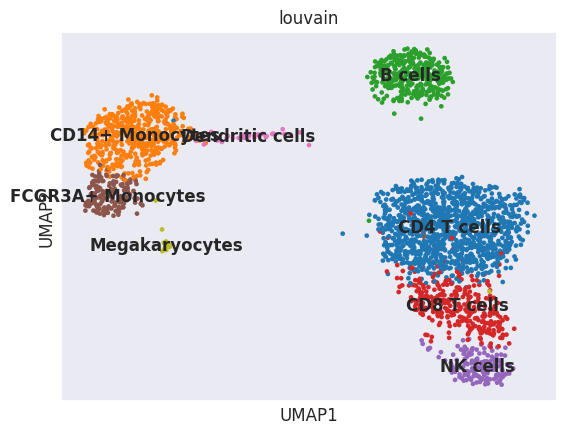

In [ ]:
import scanpy as sc
import pandas as pd

# Download the classic PBMC3k dataset
adata = sc.datasets.pbmc3k_processed()
print(adata)

# This gives you a pre-processed dataset with:
# - 2,638 cells × 1,838 genes
# - UMAP, PCA, and clustering already computed
# - Cell type annotations

# Basic exploration
print("Cell types:")
print(adata.obs['louvain'].value_counts())

# Quick UMAP plot
sc.pl.umap(adata, color='louvain', legend_loc='on data')

Show Metadata Columns (Structure)

**Cell-level metadata (stored in .obs)**

In [ ]:
print("=== 🧬 Cell Metadata Columns (adata.obs) ===")
print(adata.obs.columns.tolist())

print("\n=== 🧾 First 5 Cell Metadata Rows ===")
print(adata.obs.head())

=== 🧬 Cell Metadata Columns (adata.obs) ===
['n_genes', 'percent_mito', 'n_counts', 'louvain']

=== 🧾 First 5 Cell Metadata Rows ===
                  n_genes  percent_mito  n_counts          louvain
index                                                             
AAACATACAACCAC-1      781      0.030178    2419.0      CD4 T cells
AAACATTGAGCTAC-1     1352      0.037936    4903.0          B cells
AAACATTGATCAGC-1     1131      0.008897    3147.0      CD4 T cells
AAACCGTGCTTCCG-1      960      0.017431    2639.0  CD14+ Monocytes
AAACCGTGTATGCG-1      522      0.012245     980.0         NK cells


**Gene-level metadata (stored in .var)**

In [ ]:
print("\n=== 🧬 Gene Metadata Columns (adata.var) ===")
print(adata.var.columns.tolist())

print("\n=== 🧬 First 5 Gene Metadata Rows ===")
print(adata.var.head())

# Add a new column "gene_name" from the index
adata.var["gene_name"] = adata.var.index

# Preview the updated gene metadata
print("\n=== 🧬 Updated Gene Metadata ===")
print(adata.var.head())

adata.var_names = adata.var["gene_name"]
print(adata.var.head())


=== 🧬 Gene Metadata Columns (adata.var) ===
['n_cells']

=== 🧬 First 5 Gene Metadata Rows ===
         n_cells
index           
TNFRSF4      155
CPSF3L       202
ATAD3C         9
C1orf86      501
RER1         608

=== 🧬 Updated Gene Metadata ===
         n_cells gene_name
index                     
TNFRSF4      155   TNFRSF4
CPSF3L       202    CPSF3L
ATAD3C         9    ATAD3C
C1orf86      501   C1orf86
RER1         608      RER1
           n_cells gene_name
gene_name                   
TNFRSF4        155   TNFRSF4
CPSF3L         202    CPSF3L
ATAD3C           9    ATAD3C
C1orf86        501   C1orf86
RER1           608      RER1


In [ ]:
import os
os.makedirs("/content/pbmc_input_adata_from_scanpy_package", exist_ok=True)

# Save to loom format
adata.write_loom("/content/pbmc_input_adata_from_scanpy_package/adata_from_scanpy_package.loom")

The loom file will lack these fields:
{'X_tsne', 'X_draw_graph_fr', 'X_umap', 'PCs', 'X_pca'}
Use write_obsm_varm=True to export multi-dimensional annotations


In [ ]:
!ls -1 /content/pbmc_input_adata_from_scanpy_package/

adata_from_scanpy_package.loom
pbmc6_fixed.loom


In [ ]:
import pickle

# Step 1: Load gene symbol → Ensembl ID mapping
with open("/content/Geneformer/geneformer/gene_name_id_dict_gc104M.pkl", "rb") as f:
    gene_name_to_ensembl = pickle.load(f)

# Step 2: Make sure gene_name column exists
adata.var["gene_name"] = adata.var.index

# Step 3: Map gene symbols → Ensembl IDs
adata.var["ensembl_id"] = adata.var["gene_name"].map(gene_name_to_ensembl)

# ✅ Step 4: Drop genes without valid mapping (filter columns)
adata = adata[:, adata.var["ensembl_id"].notnull()].copy()

# Step 5: Optional — set gene symbols or Ensembl as .var_names
adata.var_names = adata.var["gene_name"]  # or use "ensembl_id"

# Step 6: Save to loom
adata.write_loom("/content/pbmc_input_adata_from_scanpy_package/pbmc6_fixed.loom")


The loom file will lack these fields:
{'X_tsne', 'X_draw_graph_fr', 'X_umap', 'PCs', 'X_pca'}
Use write_obsm_varm=True to export multi-dimensional annotations


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

gdrive_path = "/content/drive/My Drive/geneformer_test1"
adata.write_loom(gdrive_path + "pbmc6_scanpy_with_ensembl_id.loom")

The loom file will lack these fields:
{'X_tsne', 'X_draw_graph_fr', 'X_umap', 'PCs', 'X_pca'}
Use write_obsm_varm=True to export multi-dimensional annotations


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Preview the updated gene metadata
print("\n=== 🧬 Updated Gene Metadata ===")
print(adata.var.head())

adata.var_names = adata.var["gene_name"]
print(adata.var.head())


=== 🧬 Updated Gene Metadata ===
           n_cells gene_name       ensembl_id
gene_name                                    
TNFRSF4        155   TNFRSF4  ENSG00000186827
ATAD3C           9    ATAD3C  ENSG00000215915
RER1           608      RER1  ENSG00000157916
TNFRSF25       170  TNFRSF25  ENSG00000215788
TNFRSF9         11   TNFRSF9  ENSG00000049249
           n_cells gene_name       ensembl_id
gene_name                                    
TNFRSF4        155   TNFRSF4  ENSG00000186827
ATAD3C           9    ATAD3C  ENSG00000215915
RER1           608      RER1  ENSG00000157916
TNFRSF25       170  TNFRSF25  ENSG00000215788
TNFRSF9         11   TNFRSF9  ENSG00000049249


In [ ]:
!ls -1 /content/pbmc_input_adata_from_scanpy_package/

adata_from_scanpy_package.loom
pbmc6_fixed.loom


In [ ]:
from geneformer import TranscriptomeTokenizer

tokenizer6 = TranscriptomeTokenizer(
    custom_attr_name_dict={
                "louvain": "louvain"                 # example of clustering labels
    },
    gene_median_file="/content/Geneformer/geneformer/gene_median_dictionary_gc104M.pkl",
    token_dictionary_file="/content/Geneformer/geneformer/token_dictionary_gc104M.pkl",
    gene_mapping_file="/content/Geneformer/geneformer/gene_name_id_dict_gc104M.pkl",  # ⚠️ critical
    collapse_gene_ids=True,
    model_input_size=4096,
    special_token=True,
    model_version="V2"
)

In [ ]:
from datasets import load_from_disk

# Load the tokenized dataset (it's a directory, not a file)
token_data6 = load_from_disk("/content/pbmc_token6/pbmc6_tokens.dataset")

# Show the structure
print("\n• Dataset structure:")
print(f"Type: {type(token_data6)}")
print(f"Features: {token_data6.features}")

# Explore the tokenized entries
print(f"• Number of tokenized samples: {len(token_data6)}")

# View the first tokenized sample
print("\n• First tokenized entry:")
print(token_data6[0])

print("\n• Second tokenized entry:")
print(token_data6[1])

print("\n• Third tokenized entry:")
print(token_data6[2])

print("\n• 2698 tokenized entry:")
print(token_data6[2697])

print("\n• 2699 tokenized entry:")
print(token_data6[2698])

print("\n• 2700 tokenized entry:")
print(token_data6[2699])


• Dataset structure:
Type: <class 'datasets.arrow_dataset.Dataset'>
Features: {'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'louvain': Value(dtype='string', id=None), 'length': Value(dtype='int64', id=None)}
• Number of tokenized samples: 5276

• First tokenized entry:
{'input_ids': [2, 3024, 17311, 12131, 11040, 10792, 17161, 7579, 4989, 5521, 4913, 11095, 15010, 664, 17782, 5908, 9881, 1775, 11321, 6279, 4606, 2044, 10197, 17617, 5861, 17941, 9661, 12413, 15372, 5456, 50, 7838, 15549, 1859, 12429, 401, 114, 5414, 17083, 4660, 6053, 14281, 11516, 15583, 17587, 3661, 6375, 5134, 1987, 14546, 12269, 7715, 3514, 12316, 777, 3103, 5567, 16419, 1329, 12616, 8552, 2620, 8213, 6337, 18803, 6868, 5004, 1858, 4407, 933, 2056, 7551, 2774, 4399, 2198, 7488, 12817, 5616, 7326, 8151, 14262, 11750, 4504, 3786, 14709, 1720, 12394, 18264, 8006, 18331, 12240, 16363, 8719, 2349, 8340, 4016, 1825, 2262, 11797, 242, 2112, 12484, 3626, 8706, 8497, 12990, 5177, 4626, 2

In [ ]:
# to copy the results that were deposited in the folder :
output_directory="/content/pbmc_token6/"
# to gdrive :

import shutil
import os

# Step 1: Define paths
src_path = "/content/pbmc_token6/"
dest_folder = "/content/drive/My Drive/geneformer_test1/pbmc6_scanpy_with_ensembl_id/"

# Step 2: Make sure destination directory exists
os.makedirs(dest_folder, exist_ok=True)

# Step 3: Copy entire directory
shutil.copytree(src_path, dest_folder, dirs_exist_ok=True)

print("✅ Tokenized dataset copied to Google Drive successfully!")

✅ Tokenized dataset copied to Google Drive successfully!
